In [53]:
# 라이브러리 불러오기
import selenium.webdriver as wb
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
import time
from tqdm import tqdm
import pandas as pd
import re # 정규표현식
from kiwipiepy import Kiwi # 키위 형태소 분석기
from wordcloud import WordCloud # 워드클라우드 생성 도구
from collections import Counter # 단어가 나온 횟수를 세주는 도구
import matplotlib.pyplot as plt #t시각화도구
from nltk.util import ngrams

# 문자열 전처리 함수 -> 숫자, 문자, (?.!,¿) 제외하고 공백으로 대체
def preprocess_sentence_kr(w):
  w = w.strip()
  w = re.sub(r"[^0-9가-힣?.!,¿]+", " ", w) 
  w = w.strip() 
  return w

def make_bi_token(tokens):
    bi_tokens = list(ngrams(tokens,2))
    return tokens + [' '.join(bi) for bi in bi_tokens]


stopwords = set([
    '결혼', '준비', '때', '여자', '아내', '남편', '친구','남자', '정도', '남친','여친','혼수','스트레스' ,'생각','부모','얘기','어머니','아버지'
    '엄마', '아빠'
])

In [34]:
driver = wb.Chrome()
driver.get('https://www.naver.com/')
# 검생창의 위치를 드라이버에게 공유
driver.find_element(By.ID,'query').send_keys('혼수 준비 스트레스'+'\n')

In [35]:
tab = driver.find_elements(By.CSS_SELECTOR,'a.tab') 
tab[3].click()

In [36]:
for i in range(10):
    body = driver.find_element(By.TAG_NAME,'body')
    body.send_keys(Keys.END)
    time.sleep(1)

In [37]:
href_list=[]
link = driver.find_elements(By.CSS_SELECTOR,'a.fender-ui_228e3bd1.Rs_em813vSUGAmLIfR2K')
for i in range(len(link)):
    href_list.append(link[i].get_attribute('href'))

In [38]:
href_list

['https://kin.naver.com/qna/detail.naver?d1id=6&dirId=60204&docId=480206180&enc=utf8&kinsrch_src=pc_tab_kin&qb=7Zi87IiYIOykgOu5hCDsiqTtirjroIjsiqQ%3D',
 'https://kin.naver.com/qna/detail.naver?d1id=6&dirId=60212&docId=484370831&enc=utf8&kinsrch_src=pc_tab_kin&qb=7Zi87IiYIOykgOu5hCDsiqTtirjroIjsiqQ%3D',
 'https://kin.naver.com/qna/detail.naver?d1id=8&dirId=80101&docId=258115542&enc=utf8&kinsrch_src=pc_tab_kin&qb=7Zi87IiYIOykgOu5hCDsiqTtirjroIjsiqQ%3D',
 'https://kin.naver.com/qna/detail.naver?d1id=8&dirId=80801&docId=166740711&enc=utf8&kinsrch_src=pc_tab_kin&qb=7Zi87IiYIOykgOu5hCDsiqTtirjroIjsiqQ%3D',
 'https://kin.naver.com/qna/detail.naver?d1id=6&dirId=60204&docId=60445960&enc=utf8&kinsrch_src=pc_tab_kin&qb=7Zi87IiYIOykgOu5hCDsiqTtirjroIjsiqQ%3D',
 'https://kin.naver.com/qna/detail.naver?d1id=5&dirId=501&docId=481655727&enc=utf8&kinsrch_src=pc_tab_kin&qb=7Zi87IiYIOykgOu5hCDsiqTtirjroIjsiqQ%3D',
 'https://kin.naver.com/qna/detail.naver?d1id=7&dirId=7010102&docId=485229283&enc=utf8&kins

In [39]:
len(href_list)

110

In [40]:
driver.get(href_list[0])
time.sleep(2)
result=driver.find_elements(By.CSS_SELECTOR,'div.questionDetail')
result[0].text

'Lh 신생아 부분으로 당첨되서 집구하고 집보증금 1250만원 남편쪽에서 해왔습니다\n그러다 가전을 사야대는대 살림에 잇어 냉장고랑 세탁기만 놓고살라더라구요\n전싫다 최소한의기본 냉장고 청소기 에어컨 세탁기 이네개만 구매한다고해도 두개만사라고소리지르고 아주쌩난리를 치십니다\n본인사주는것도 아닌데 왜이리 결혼생활에 간섭이신지... 그래서 알아서한다고하니 살림다차려서살고싶으면 남편쪽에서1250해왔으니 혼수다해오라네요\n개빡치는데 그럼 전통방식마냥 혼수 다해갈테니 집보증금말고 집해오라고 해도 될까요'

In [41]:
f = open('./data/혼수 준비 스트레스.txt','w')

# 링크 반복
for i in tqdm(range(len(href_list))):
    driver.get(href_list[i])
    time.sleep(2)


    result=driver.find_elements(By.CSS_SELECTOR,'div.questionDetail')
    for j in range(len(result)):
        content = preprocess_sentence_kr(result[j].text)
        f.write(content)

f.close()   
driver.quit()

100%|██████████| 110/110 [04:57<00:00,  2.70s/it]


In [42]:
# 텍스트 파일 열기
f = open('./data/혼수 준비 스트레스.txt','r')
text = f.readline()
f.close()

In [54]:
kiwi = Kiwi()
token = kiwi.tokenize(text)

nn_list=[]
for t in token:
    if t.tag in ['NNG','NNP']:
        w = t.form
        if len(w) >= 2 and w not in stopwords:
            nn_list.append(w)

In [55]:
nn_list=make_bi_token(nn_list)

In [56]:
top_100 = Counter(nn_list).most_common(100)
top_100

[('비용', 64),
 ('결혼식', 61),
 ('신부', 59),
 ('예단', 57),
 ('상태', 44),
 ('문제', 42),
 ('사람', 42),
 ('생활', 41),
 ('신랑', 41),
 ('이혼', 41),
 ('웨딩', 41),
 ('상황', 40),
 ('신혼', 40),
 ('엄마', 39),
 ('부탁', 36),
 ('본인', 34),
 ('아버지', 33),
 ('안녕', 32),
 ('가구', 32),
 ('질문', 31),
 ('시댁', 31),
 ('시간', 31),
 ('동안', 30),
 ('말씀', 30),
 ('상견례', 29),
 ('언니', 29),
 ('오빠', 28),
 ('이야기', 28),
 ('전화', 28),
 ('어머님', 28),
 ('가전', 27),
 ('걱정', 27),
 ('예비', 27),
 ('시작', 27),
 ('요구', 27),
 ('아들', 27),
 ('와이프', 27),
 ('부담', 26),
 ('얼마', 25),
 ('마음', 25),
 ('대출', 25),
 ('아파트', 25),
 ('이유', 25),
 ('장모', 25),
 ('지금', 24),
 ('임신', 24),
 ('예물', 24),
 ('계약', 23),
 ('파혼', 23),
 ('도움', 23),
 ('공부', 23),
 ('형편', 23),
 ('직장', 23),
 ('친정', 23),
 ('이상', 22),
 ('이번', 22),
 ('아이', 22),
 ('전세', 21),
 ('고민', 21),
 ('경우', 21),
 ('처가', 21),
 ('답변', 20),
 ('수술', 20),
 ('처음', 20),
 ('반지', 20),
 ('시어머니', 20),
 ('문자', 20),
 ('한복', 20),
 ('집안', 19),
 ('애기', 19),
 ('부친', 19),
 ('티비', 18),
 ('병원', 18),
 ('부분', 17),
 ('연락', 17),
 ('필요', 17),
 ('

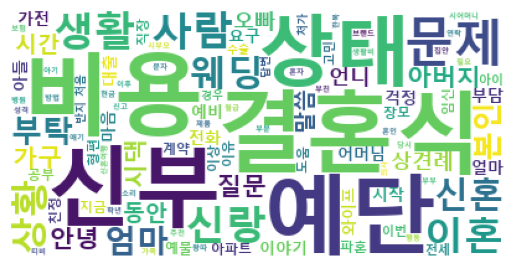

In [57]:
wc = WordCloud(
    font_path='C:/Windows/Fonts/malgunbd.ttf',
    background_color='white'    
).generate_from_frequencies(dict(top_100))
plt.imshow(wc)
plt.axis('off')
plt.show()